In [27]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, defaultdict

In [2]:
local_repository = True
script_dir = os.path.dirname(os.path.abspath("__file__"))  #alternative os.path.dirname(os.path.abspath(''))
if local_repository:
    sys.path.insert(1, "{}/dromi/src".format(script_dir))
    import dromi
else:  # pip installed module
    import dromi
import dromi.utils as DromiUtils
import dromi.similarities as DromiSimilarities
from Dromi_example import select_plots

storage_folder = script_dir
unique_characters = 21
blosum_array, blosum_dict, blosum_array_dict = DromiUtils.create_blosum(unique_characters, "BLOSUM62",
                                                                        zero_characters=["#"],
                                                                        include_zero_characters=True)

Loading dromi module from /home/lys/Dropbox/PostDoc/dromi/dromi/src/dromi/__init__.py


In [3]:
#Datasets examples for checking correctness of the algorithm
# seqs = ["AHPDYRMPIL"] * 1000
seqs = ["AHPDYRM",
        "AHPHYRM",
        "AKPDYRM",
        "AHPDYRM",
        "AHPDYRM",
        "FYRA",
        "MRSTVI"]
# seqs = [
#     "RGICWMLV",
#     "RGICWMLV",
#     "RGVCWMLV",
#     "RGVCWMLV",
#     "RGACWMLV",
#     "RGACFMLV",
#     "RGLCYMLV",
#     "RGLCYMLV",
#     "RGICYMLV",
#     "RGICYMLV",
# ]
max_len = len(max(seqs, key=len))

padding_result = DromiUtils.SequencePadding(seqs, max_len, method="ends", shuffle=False).run()
sequences, sequences_padded = zip(*padding_result)  # unpack list of tuples onto 2 lists

aa_dict = DromiUtils.aminoacid_names_dict(21, zero_characters=["#"])
sequences_array = np.array(sequences_padded)
sequences_int = np.vectorize(aa_dict.get)(sequences_array)
sequences_blosum = np.vectorize(blosum_array_dict.get, signature='()->(n)')(sequences_int)
sequences_mask = sequences_int.astype(bool)


In [4]:
#Highlight: Check correctness of the results
args = namedtuple('Arguments', ['analysis', 'runtime', 'metric', 'calculate_kmers', 'calculate_positional_weights'])(
    "similarities", "ram", "all", True, True)
results, runtime = DromiSimilarities.calculate_similarities(sequences_blosum, max_len, sequences_mask, storage_folder,
                                                            batch_size=5,
                                                            ksize=3,
                                                            neighbours=1,
                                                            metric=args.metric,
                                                            calculate_kmers=args.calculate_kmers,
                                                            calculate_positional_weights=args.calculate_positional_weights)

print(results)
select_plots(args, results, storage_folder, "_correctness")

Generated 1 splits from 7 data points
Overall calculation time 0:00:00.176453
Calculating positional importance weights based on neighbouring-aminoacids cosine similarity
Done calculating indexes
Done calculating the masked average
Finished positional weights
SimilarityResults(positional_weights=array([[0.74949137, 0.74739583, 0.82096354, 0.69018555, 0.71325684,
        0.67172496, 0.66666667],
       [0.74949137, 0.74739583, 0.82096354, 0.30566915, 0.71325684,
        0.67172496, 0.66666667],
       [0.74949137, 0.41771698, 0.82096354, 0.69018555, 0.71325684,
        0.67172496, 0.66666667],
       [0.74949137, 0.74739583, 0.82096354, 0.69018555, 0.71325684,
        0.67172496, 0.66666667],
       [0.74949137, 0.74739583, 0.82096354, 0.69018555, 0.71325684,
        0.67172496, 0.66666667],
       [0.20957438, 0.37766774, 0.45027669, 0.31952413, 0.        ,
        0.        , 0.        ],
       [0.38667806, 0.51431274, 0.4934082 , 0.39857992, 0.23295085,
        0.02529144, 0.       

In [5]:
#Highlight: Create and save dataset for runtime bechmarking
seq_len = 80
nseqs = 200
pad_til = max_seq_len = 50
random_result = DromiUtils.SequenceRandomGeneration(["".join(["A"] * seq_len)] * nseqs, pad_til,
                                                    "ends").run()  #creates random amino acid sequences

seqs, sequences_padded = zip(*random_result)  #TODO: Just return seqs, seqs were supposed to be unpadded
max_len = len(max(seqs, key=len))

aa_dict = DromiUtils.aminoacid_names_dict(21, zero_characters=["#"])
sequences_array = np.array(sequences_padded)
sequences_int = np.vectorize(aa_dict.get)(sequences_array)
sequences_blosum = np.vectorize(blosum_array_dict.get, signature='()->(n)')(sequences_int)
sequences_mask = sequences_int.astype(bool)

np.save(f"{storage_folder}/sequences_blosum_nseqs{nseqs}_maxlen{max_len}.npy", sequences_blosum)
np.save(f"{storage_folder}/sequences_mask_nseqs{nseqs}_maxlen{max_len}.npy", sequences_mask)



In [21]:
runtimes_dict = defaultdict(list)

In [10]:
args = namedtuple('Arguments', ['analysis', 'runtime', 'metric', 'calculate_kmers', 'calculate_positional_weights'])(
    "similarities", "ram", "all", False, False)

datasets = {
    0: [200, 80],
    1: [300, 50],
    2: [1000, 50],
    3: [100, 400]
}

nseqs, max_len = datasets[0]
sequences_blosum = np.load(f"{storage_folder}/sequences_blosum_nseqs{nseqs}_maxlen{max_len}.npy")
sequences_mask = np.load(f"{storage_folder}/sequences_mask_nseqs{nseqs}_maxlen{max_len}.npy")

In [24]:
#Highlight: Benchmark average runtime across different datasets
batch_size = 10
results, runtime = DromiSimilarities.calculate_similarities(sequences_blosum, max_len, sequences_mask,
                                                            storage_folder,
                                                            batch_size=batch_size,
                                                            ksize=3,
                                                            neighbours=1,
                                                            metric=args.metric,
                                                            calculate_kmers=args.calculate_kmers,
                                                            calculate_positional_weights=args.calculate_positional_weights)

runtimes_dict[f"nseqs{nseqs}_maxlen{max_len}_batchsize{batch_size}"].append(runtime.total_seconds())
#TODO: Test without gc.collect()


Generated 20 splits from 200 data points
Overall calculation time 0:00:23.612522


In [25]:
print(runtimes_dict)

defaultdict(<class 'list'>, {'nseqs200_maxlen80_batchsize10': [22.876595, 22.952806, 23.612522]})


AttributeError: 'Line2D' object has no property 'facecolor'

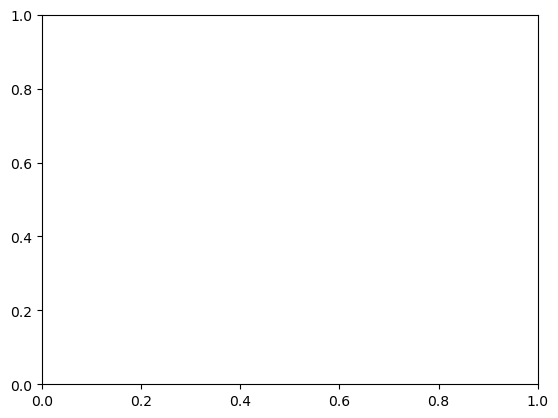

In [34]:
plt.rcParams['figure.facecolor'] = 'white'

plt.plot(list(range(len(runtimes_dict.keys()))), [np.mean(vals) for vals in runtimes_dict.values()], color="red")
plt.show()